In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
X = np.array([1,2,3,4,5,6,7,8,9,10])
Y = np.array([1.5,1.8,3.2,3.9,5.1,5.8,6.9,8.2,8.8,10.1])

In [4]:
X_matrix = np.column_stack((np.ones(len(X)),X))

In [5]:
def gaussian_weights(query_point,X,tau):
    m = X.shape[0]
    weights = np.eye(m)
    for i in range(m):
        diff = query_point-X[i]
        weights[i,i]= np.exp(np.dot(diff,diff)/(-2*tau*tau))
        return weights

In [8]:
def locally_weighted_regression(query_point,X,Y,tau):
    w = gaussian_weights(query_point,X,tau)
    theta = np.linalg.inv(X.T @ w @ X)@(X.T @ w @ Y)
    prediction = query_point @ theta
    return prediction

In [15]:
tau = 0.5
predictions = []
for point in X_matrix:
    predictions.append(
        locally_weighted_regression(point,X_matrix,Y,tau)
    )
predictions = np.array(predictions)

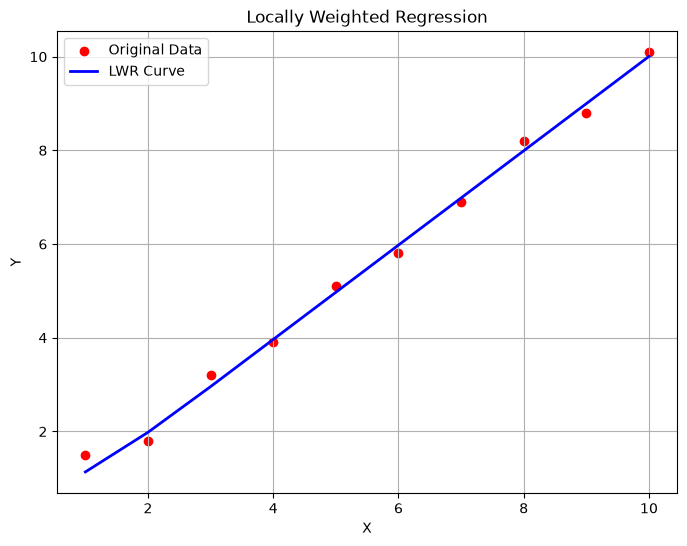

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(X,Y,color='red',label="Original Data")
plt.plot(X,predictions,
         color='blue',
         linewidth=2,
         label="LWR Curve")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Locally Weighted Regression")
plt.legend()
plt.grid(True)
plt.show()